In [12]:
import numpy as np
import json

from sklearn.datasets import make_multilabel_classification

from sklearn.multiclass import OneVsRestClassifier
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd

In [2]:
import sys
sys.path.append("..")

In [3]:
from src.data.formatting import resample_data_set
from src.conformal_risk_control.fnr import compute_prediction_set
from src.model_selection.fnr_oracle import compute_oracle_prediction_set
from src.model_selection.fnr_upper import compute_upper_prediction_set
from src.model_selection.fnr_split import select_predictor_index

In [4]:
def reader(path_params):
    with open(path_params, "r") as file:
        params = json.load(file)
    print(params)
    return params

In [5]:
def generate_data_set(params):
    inputs_, outputs_ = make_multilabel_classification(
        n_samples=params["sample_size"] + 1,
        n_features=params["feature_number"],
        n_classes=params["label_number"],
        n_labels=params["avg_label_number"],
        allow_unlabeled=False,
        return_indicator=True,
    )
    return inputs_, outputs_

In [13]:
params_global = reader("params/experiment_2.json")
lam = 10

{'data': {'sample_size': 500, 'feature_number': 300, 'label_number': 10, 'avg_label_number': 4, 'cal_size': 0.3, 'proper_cal_size': 0.5}, 'predictor': {'n_estimators_min': 10, 'n_estimators_max': 100, 'criterion': ['gini', 'entropy'], 'lam_numbers': ['14', '22', '32', '38']}, 'risk': {'control_level': 0.25}}


In [45]:
complete_n_estimators_grid = np.arange(params_global["predictor"]["n_estimators_min"], params_global["predictor"]["n_estimators_max"]+1)
np.random.shuffle(complete_n_estimators_grid)
n_estimators_grid = complete_n_estimators_grid[: 11]
print(n_estimators_grid)

[89 26 86 66 73 18 99 91 53 32 76]


In [46]:
parameter_grid =  np.array(
    [
        {"n_estimators": n_estimators, "criterion": criterion}
        for n_estimators in n_estimators_grid
        for criterion in params_global["predictor"]["criterion"]
    ], dtype = object
)
print(parameter_grid)

[{'n_estimators': np.int64(89), 'criterion': 'gini'}
 {'n_estimators': np.int64(89), 'criterion': 'entropy'}
 {'n_estimators': np.int64(26), 'criterion': 'gini'}
 {'n_estimators': np.int64(26), 'criterion': 'entropy'}
 {'n_estimators': np.int64(86), 'criterion': 'gini'}
 {'n_estimators': np.int64(86), 'criterion': 'entropy'}
 {'n_estimators': np.int64(66), 'criterion': 'gini'}
 {'n_estimators': np.int64(66), 'criterion': 'entropy'}
 {'n_estimators': np.int64(73), 'criterion': 'gini'}
 {'n_estimators': np.int64(73), 'criterion': 'entropy'}
 {'n_estimators': np.int64(18), 'criterion': 'gini'}
 {'n_estimators': np.int64(18), 'criterion': 'entropy'}
 {'n_estimators': np.int64(99), 'criterion': 'gini'}
 {'n_estimators': np.int64(99), 'criterion': 'entropy'}
 {'n_estimators': np.int64(91), 'criterion': 'gini'}
 {'n_estimators': np.int64(91), 'criterion': 'entropy'}
 {'n_estimators': np.int64(53), 'criterion': 'gini'}
 {'n_estimators': np.int64(53), 'criterion': 'entropy'}
 {'n_estimators': n

In [47]:
predictors = [
    OneVsRestClassifier(RandomForestClassifier(**parameter)) for parameter in parameter_grid
]

In [48]:
rep_number = 100

In [49]:
results = {
    "size":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
        "Output":[],
    }, "FNR":{
        "Oracle":[],
        "Upper":[],
        "Split":[],
    }
}

In [50]:
for rep_index in tqdm(range(rep_number)):
    inputs_, outputs_ = generate_data_set(params_global["data"])

    (
        (scaled_inputs_train, outputs_train),
        (scaled_inputs_calibration, outputs_calibration),
        (
            scaled_inputs_selection,
            scaled_inputs_proper_cal,
            outputs_selection,
            outputs_proper_cal,
        ),
        (scaled_input_test, output_test),
    ) = resample_data_set(inputs_, outputs_, params_global["data"]["cal_size"], params_global["data"]["proper_cal_size"])


    for predictor in predictors:
        predictor.fit(scaled_inputs_train, outputs_train)


    probas_calibration_per_predictor = [
        predictor.predict_proba(scaled_inputs_calibration) for predictor in predictors
    ]
    proba_test_per_predictor = [
        predictor.predict_proba(scaled_input_test) for predictor in predictors
    ]
    oracle_prediction_set = compute_oracle_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        output_test,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )

    
    upper_prediction_set = compute_upper_prediction_set(
        outputs_calibration,
        probas_calibration_per_predictor,
        proba_test_per_predictor,
        params_global["risk"]["control_level"],
    )



    probas_selection_per_predictor = [
        predictor.predict_proba(scaled_inputs_selection) for predictor in predictors
    ]
    split_predictor_index = select_predictor_index(
        outputs_selection, probas_selection_per_predictor, params_global["risk"]["control_level"]
    )
    split_prediction_set = compute_prediction_set(
        predictors[split_predictor_index],
        scaled_inputs_proper_cal,
        outputs_proper_cal,
        scaled_input_test,
        params_global["risk"]["control_level"]
    )

    oracle_fnr = (
        np.logical_and(output_test, np.logical_not(oracle_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    upper_fnr = (
        np.logical_and(output_test, np.logical_not(upper_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    split_fnr = (
        np.logical_and(output_test, np.logical_not(split_prediction_set)).sum(axis=1)
        / output_test.sum(axis=1)
    ).item()
    
    results["FNR"]["Oracle"].append(oracle_fnr)
    results["FNR"]["Upper"].append(upper_fnr)
    results["FNR"]["Split"].append(split_fnr)

    results["size"]["Oracle"].append(oracle_prediction_set.sum())
    results["size"]["Upper"].append(upper_prediction_set.sum())
    results["size"]["Split"].append(split_prediction_set.sum())
    results["size"]["Output"].append(output_test.sum())

    
    print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
    print("Average output size: {}".format(np.mean(results["size"]["Output"])))
    print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
    print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))


  1%|          | 1/100 [00:28<46:26, 28.14s/it]

Average oracle prediction-set size: 6.0
Average output size: 2.0
Average split prediction-set size: 7.0
Average upper prediction-set size: 7.0


  2%|▏         | 2/100 [00:56<46:26, 28.43s/it]

Average oracle prediction-set size: 5.0
Average output size: 2.0
Average split prediction-set size: 6.5
Average upper prediction-set size: 5.5


  3%|▎         | 3/100 [01:28<48:36, 30.07s/it]

...

Average oracle prediction-set size: 5.5
Average output size: 4.0
Average split prediction-set size: 5.8
Average upper prediction-set size: 6.433333333333334


 31%|███       | 31/100 [14:54<32:59, 28.69s/it]

Average oracle prediction-set size: 5.516129032258065
Average output size: 4.032258064516129
Average split prediction-set size: 5.806451612903226
Average upper prediction-set size: 6.419354838709677


 31%|███       | 31/100 [15:19<34:06, 29.66s/it]


KeyboardInterrupt: 

In [170]:
print("Average oracle prediction-set size: {}".format(np.mean(results["size"]["Oracle"])))
print("Average output size: {}".format(np.mean(results["size"]["Output"])))
print("Average split prediction-set size: {}".format(np.mean(results["size"]["Split"])))
print("Average upper prediction-set size: {}".format(np.mean(results["size"]["Upper"])))

Average oracle prediction-set size: 5.31
Average output size: 3.66
Average split prediction-set size: 5.52
Average upper prediction-set size: 6.49


In [171]:
df_volume = pd.DataFrame.from_dict(
    results["size"]
)

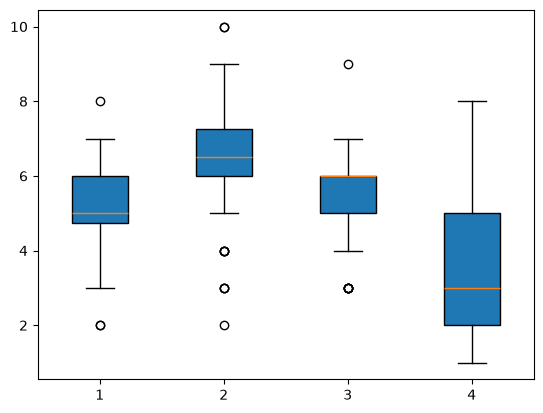

In [172]:
fig, ax = plt.subplots()
box = ax.boxplot(df_volume, patch_artist=True)

In [173]:
print("Average oracle prediction-set FNR: {}".format(np.mean(results["FNR"]["Oracle"])))
print("Average split prediction-set FNR: {}".format(np.mean(results["FNR"]["Split"])))
print("Average upper prediction-set FNR: {}".format(np.mean(results["FNR"]["Upper"])))

Average oracle prediction-set FNR: 0.23871428571428574
Average split prediction-set FNR: 0.28064285714285714
Average upper prediction-set FNR: 0.17135714285714287


In [174]:
df_fnr = pd.DataFrame.from_dict(
    results["FNR"]
)

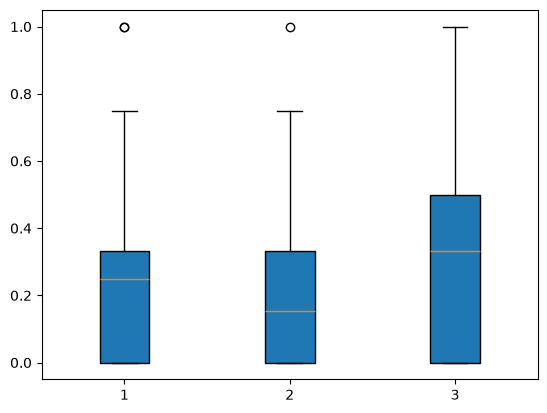

In [175]:
fig, ax = plt.subplots()
box = ax.boxplot(df_fnr, patch_artist=True)